In [263]:
from ai_edge_litert.interpreter import Interpreter
interpreter = Interpreter(model_path="palm_detection_full.tflite")
interpreter.allocate_tensors()

# Get input and output details
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

In [264]:
input_details

[{'name': 'input_1',
  'index': 0,
  'shape': array([  1, 192, 192,   3], dtype=int32),
  'shape_signature': array([  1, 192, 192,   3], dtype=int32),
  'dtype': numpy.float32,
  'quantization': (0.0, 0),
  'quantization_parameters': {'scales': array([], dtype=float32),
   'zero_points': array([], dtype=int32),
   'quantized_dimension': 0,
   'block_size': 0},
  'sparsity_parameters': {}}]

In [265]:
import numpy as np

def generate_palm_anchors():
    input_w, input_h = 192, 192
    strides = [8, 16, 16, 16]
    min_scale = 0.1484375
    max_scale = 0.75
    num_layers = 4

    anchors = []
    for layer_idx in range(num_layers):
        stride = strides[layer_idx]
        feat_w = input_w // stride
        feat_h = input_h // stride

        scale = min_scale + (max_scale - min_scale) * layer_idx / (num_layers - 1)
        scale_next = min_scale + (max_scale - min_scale) * (layer_idx + 1) / (num_layers - 1) \
                     if layer_idx + 1 < num_layers else 1.0
        interp_scale = np.sqrt(scale * scale_next)

        anchor_specs = [(scale, 1.0), (interp_scale, 1.0)]

        for row in range(feat_h):
            for col in range(feat_w):
                x_center = (col + 0.5) / feat_w
                y_center = (row + 0.5) / feat_h
                for _ in anchor_specs:
                    anchors.append([x_center, y_center, 1.0, 1.0])

    return np.array(anchors, dtype=np.float32)  # (2016, 4)


def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))


def decode_best_detection(raw_boxes, raw_scores):
    """
    raw_boxes:  (1, 2016, 18) - raw regression output from palm detector
    raw_scores: (1, 2016, 1)  - raw logit scores from palm detector

    Returns the decoded box and keypoints (in pixels) for the highest-confidence anchor.
    """
    input_size = 192.0

    # --- Strip batch dimension ---
    boxes  = raw_boxes[0]   # (2016, 18)
    scores = raw_scores[0]  # (2016, 1)

    # --- Find highest confidence anchor ---
    confidences = sigmoid(scores[:, 0])   # (2016,) - convert logits to probabilities
    best_idx = np.argmax(confidences)
    best_conf = confidences[best_idx]

    print(f"Best anchor index: {best_idx}")
    print(f"Confidence: {best_conf:.4f}")

    # --- Retrieve the corresponding anchor and raw prediction ---
    anchors = generate_palm_anchors()
    anchor  = anchors[best_idx]           # [x_center, y_center, w, h] normalized
    raw     = boxes[best_idx]             # (18,)

    # Anchor center in pixels
    ax = anchor[0] * input_size
    ay = anchor[1] * input_size

    # --- Decode box (dy, dx, h, w) ---
    dy, dx, h, w = raw[0], raw[1], raw[2], raw[3]
    print(f"{raw[:4]=}")
    box = {
        'x_center': ax + dx,
        'y_center': ay + dy,
        'width':    w,
        'height':   h,
        # Convenience: corners
        'x_min':    ax + dx - w / 2,
        'y_min':    ay + dy - h / 2,
        'x_max':    ax + dx + w / 2,
        'y_max':    ay + dy + h / 2,
    }

    # --- Decode 7 keypoints ---
    # Each is a (dx, dy) offset from the same anchor center
    keypoint_names = [
        'wrist',
        'pinky_mcp',
        'index_mcp',
        'middle_tip',
        'index_tip',
        'thumb_tip',
        'thumb_mcp',
    ]
    keypoints = {}
    for i, name in enumerate(keypoint_names):
        kp_dx = raw[4 + 2*i]
        kp_dy = raw[4 + 2*i + 1]
        keypoints[name] = (ax + kp_dx, ay + kp_dy)

    return best_conf, box, keypoints


In [266]:
output_details

[{'name': 'Identity',
  'index': 279,
  'shape': array([   1, 2016,   18], dtype=int32),
  'shape_signature': array([   1, 2016,   18], dtype=int32),
  'dtype': numpy.float32,
  'quantization': (0.0, 0),
  'quantization_parameters': {'scales': array([], dtype=float32),
   'zero_points': array([], dtype=int32),
   'quantized_dimension': 0,
   'block_size': 0},
  'sparsity_parameters': {}},
 {'name': 'Identity_1',
  'index': 276,
  'shape': array([   1, 2016,    1], dtype=int32),
  'shape_signature': array([   1, 2016,    1], dtype=int32),
  'dtype': numpy.float32,
  'quantization': (0.0, 0),
  'quantization_parameters': {'scales': array([], dtype=float32),
   'zero_points': array([], dtype=int32),
   'quantized_dimension': 0,
   'block_size': 0},
  'sparsity_parameters': {}}]

In [267]:
import cv2
import numpy as np

def draw_palm_detection(image, box, keypoints, conf):
    """
    image:     numpy array (H, W, 3) - the original input image (any size)
    box:       dict with x_center, y_center, width, height, x_min, y_min, x_max, y_max
               all in 192x192 pixel space
    keypoints: dict of name -> (x, y) in 192x192 pixel space
    conf:      float confidence score
    """
    h, w = image.shape[:2]

    # Scale factor from 192x192 detection space back to original image size
    sx = w / 192.0
    sy = h / 192.0

    def scale(x, y):
        return (int(x * sx), int(y * sy))

    vis = image.copy()

    # --- Bounding box ---
    x_min, y_min = scale(box['x_min'], box['y_min'])
    x_max, y_max = scale(box['x_max'], box['y_max'])
    cv2.rectangle(vis, (x_min, y_min), (x_max, y_max), color=(0, 255, 0), thickness=2)

    # --- Confidence label ---
    label = f"palm {conf:.2f}"
    cv2.putText(vis, label, (x_min, y_min - 8),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

    # --- Keypoints ---
    colors = {
        'wrist':      (255,   0,   0),
        'pinky_mcp':  (255, 128,   0),
        'index_mcp':  (255, 255,   0),
        'middle_tip': (  0, 255,   0),
        'index_tip':  (  0, 255, 255),
        'thumb_tip':  (  0,   0, 255),
        'thumb_mcp':  (128,   0, 255),
    }
    for name, (kx, ky) in keypoints.items():
        pt = scale(kx, ky)
        cv2.circle(vis, pt, radius=4, color=colors[name], thickness=-1)
        cv2.putText(vis, name, (pt[0] + 5, pt[1]),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.35, colors[name], 1)

    # --- Skeleton: connect wrist to MCP joints ---
    connections = [
        ('wrist', 'pinky_mcp'),
        ('wrist', 'index_mcp'),
        ('wrist', 'thumb_mcp'),
        # ('index_mcp', 'pinky_mcp'),
    ]
    for a, b in connections:
        pt_a = scale(*keypoints[a])
        pt_b = scale(*keypoints[b])
        cv2.line(vis, pt_a, pt_b, color=(200, 200, 200), thickness=1)

    return vis

In [268]:
import numpy as np

def pipeline(path):
    from PIL import Image

    image = Image.open(path).resize((192, 192))
    image_np = np.array(image, dtype=np.uint8)
    input_data = image_np.astype(np.float32) / 255.0
                      
    input_data = np.expand_dims(input_data, axis=0)
    interpreter.set_tensor(input_details[0]['index'], input_data)
    interpreter.invoke()

    output_0 = interpreter.get_tensor(output_details[0]['index'])
    output_1 = interpreter.get_tensor(output_details[1]['index'])

    best_conf, box, keypoints = decode_best_detection(output_0, output_1)
    print(keypoints)
    vis = draw_palm_detection(image_np, box, keypoints, float(conf))
    from IPython.display import display
    from PIL import Image
    
    vis_rgb = cv2.cvtColor(vis, cv2.COLOR_BGR2RGB)
    display(Image.fromarray(vis))

Best anchor index: 1693
Confidence: 0.9527
raw[:4]=array([-1.3062286,  2.1518548, 62.524914 , 62.530823 ], dtype=float32)
{'wrist': (np.float32(127.45303), np.float32(194.81577)), 'pinky_mcp': (np.float32(79.084785), np.float32(162.1721)), 'index_mcp': (np.float32(87.76601), np.float32(152.26561)), 'middle_tip': (np.float32(97.43565), np.float32(144.75594)), 'index_tip': (np.float32(107.743454), np.float32(138.65532)), 'thumb_tip': (np.float32(104.35044), np.float32(200.37115)), 'thumb_mcp': (np.float32(83.65873), np.float32(196.93524))}


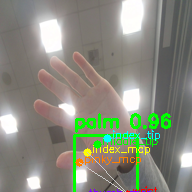

In [269]:
pipeline("IMG_20260228_100522.jpg")